# DataCo Supply Chain Analysis

## Python Analysis

This notebook investigates the DataCo SMART SUPPLY CHAIN dataset using Python.

### Objectives
- Explore distributions and patterns not fully captured by SQL aggregation
- Investigate relationships between operational and financial variables
- Test selected hypotheses statistically where appropriate
- Prepare insights and visualizations for the final Power BI presentation

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
import sys

print(sys.executable)

c:\Users\XPRISTO\anaconda3\python.exe


In [70]:
import psycopg2

print("PostgreSQL connector is ready.")

PostgreSQL connector is ready.


In [ ]:
conn = psycopg2.connect(
    host="localhost",
    database="supply_chain_project",
    user="postgres",
    password="____"
)

print("Connected to PostgreSQL successfully.")

Connected to PostgreSQL successfully.


In [72]:
query = """
select *
from supply_chain_analysis;
"""

df = pd.read_sql_query(query, conn)
df

C:\Users\XPRISTO\AppData\Local\Temp\ipykernel_21940\2142111256.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Profit Per Order,Order Region,Order State,Order Status,Product Card Id,Product Category Id,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,TRANSFER,4,4,-22.99,39.99,Shipping on time,0,29,Shop By Sport,Costa Mesa,...,-22.99,West of USA,California,PROCESSING,627,29,Under Armour Girls' Toddler Spine Surge Runni,39.99,2016-07-22,Standard Class
1,TRANSFER,3,4,23.52,49.00,Advance shipping,0,24,Women's Apparel,Azusa,...,23.52,US Center,Texas,PROCESSING,502,24,Nike Men's Dri-FIT Victory Golf Polo,50.00,2016-07-09,Standard Class
2,TRANSFER,2,4,8.40,48.00,Advance shipping,0,24,Women's Apparel,Louisville,...,8.40,West of USA,Washington,PROCESSING,502,24,Nike Men's Dri-FIT Victory Golf Polo,50.00,2016-06-14,Standard Class
3,TRANSFER,6,4,17.10,37.99,Late delivery,1,29,Shop By Sport,Las Vegas,...,17.10,East of USA,Nueva York,PROCESSING,627,29,Under Armour Girls' Toddler Spine Surge Runni,39.99,2016-07-04,Standard Class
4,TRANSFER,5,4,17.81,47.50,Late delivery,1,24,Women's Apparel,New Haven,...,17.81,US Center,Illinois,PROCESSING,502,24,Nike Men's Dri-FIT Victory Golf Polo,50.00,2016-04-27,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,TRANSFER,6,4,10.40,103.99,Late delivery,1,18,Men's Footwear,Mcallen,...,10.40,US Center,Illinois,PROCESSING,403,18,Nike Men's CJ Elite 2 TD Football Cleat,129.99,2016-07-12,Standard Class
180515,TRANSFER,6,4,35.39,97.49,Late delivery,1,18,Men's Footwear,San Ramon,...,35.39,East of USA,Pensilvania,PROCESSING,403,18,Nike Men's CJ Elite 2 TD Football Cleat,129.99,2016-08-21,Standard Class
180516,TRANSFER,6,4,25.35,97.49,Late delivery,1,18,Men's Footwear,Riverside,...,25.35,East of USA,Nueva York,PROCESSING,403,18,Nike Men's CJ Elite 2 TD Football Cleat,129.99,2016-06-02,Standard Class
180517,TRANSFER,4,4,-146.24,97.49,Shipping on time,0,18,Men's Footwear,Bronx,...,-146.24,East of USA,Nueva York,PROCESSING,403,18,Nike Men's CJ Elite 2 TD Football Cleat,129.99,2016-05-13,Standard Class


In [73]:
df.shape

(180519, 44)

In [74]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 44 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Id                    180519 non-null  int64  
 12  Customer Segment              

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Card Id,Product Category Id,Product Price
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107607,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,90260.000000,141.232547,0.120647,2.127638,203.772092,183.107607,21.974989,692.509764,31.851451,141.232547
std,1.623722,1.374449,104.433526,120.043668,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,52111.490959,139.732489,0.466796,1.453451,132.273075,120.043668,104.433526,336.446807,15.640064,139.732489
min,0.000000,0.000000,-4274.980000,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,-2.750000,1.000000,9.990000,7.490000,-4274.980000,19.000000,2.000000,9.990000
25%,2.000000,2.000000,7.000000,104.380000,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,45130.500000,50.000000,0.080000,1.000000,119.980000,104.380000,7.000000,403.000000,18.000000,50.000000
50%,3.000000,4.000000,31.520000,163.990000,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,90260.000000,59.990000,0.270000,1.000000,199.920000,163.990000,31.520000,627.000000,29.000000,59.990000
75%,5.000000,4.000000,64.800000,247.400000,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,135389.500000,199.990000,0.360000,3.000000,299.950000,247.400000,64.800000,1004.000000,45.000000,199.990000
max,6.000000,4.000000,911.800000,1939.990000,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,180519.000000,1999.990000,0.500000,5.000000,1999.990000,1939.990000,911.800000,1363.000000,76.000000,1999.990000


## 1. Profit Distribution

We will examine the distribution of Benefit per Order to understand its spread, skewness, and potential outliers.

In [75]:
df["Benefit per order"].describe()

count    180519.000000
mean         21.974989
std         104.433526
min       -4274.980000
25%           7.000000
50%          31.520000
75%          64.800000
max         911.800000
Name: Benefit per order, dtype: float64

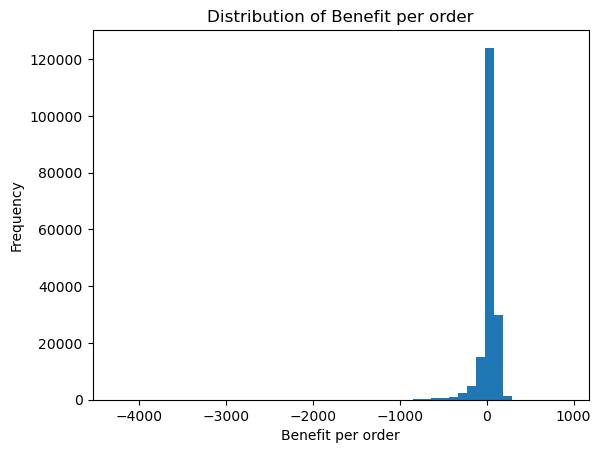

In [76]:
plt.hist(df["Benefit per order"], bins=50)

plt.xlabel("Benefit per order")
plt.ylabel("Frequency")
plt.title("Distribution of Benefit per order")

plt.show()

The histogram to be displayed between the 1st and 99th percentiles to prevent extreme observations from compressing the main distribution.

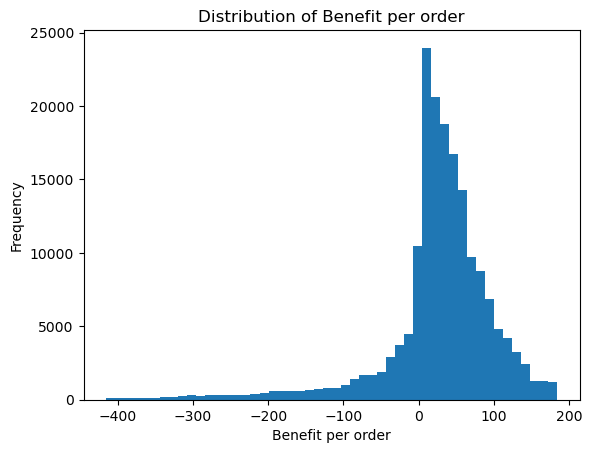

In [77]:
lower = df["Benefit per order"].quantile(0.01)
upper = df["Benefit per order"].quantile(0.99)

plt.hist(df["Benefit per order"], bins=50, range=(lower, upper))
plt.xlabel("Benefit per order")
plt.ylabel("Frequency")
plt.title("Distribution of Benefit per order")
plt.show()

>Most transactions are modestly profitable, while a smaller number of loss-making transactions create a long negative tail that pulls the average (21.98) below the median (31.52).

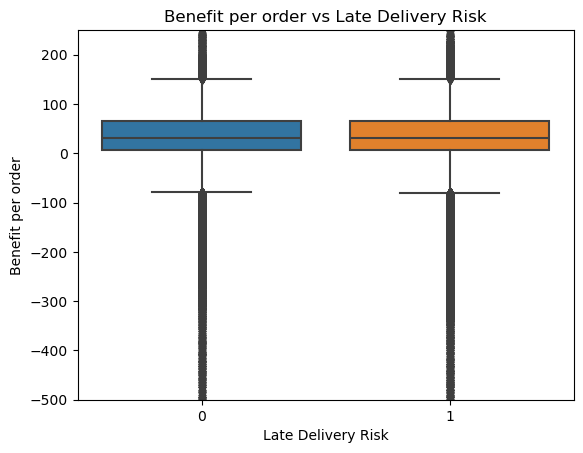

In [78]:
sns.boxplot(x=df["Late_delivery_risk"], y=df["Benefit per order"], data=df)

plt.ylim(-500, 250)
plt.xlabel("Late Delivery Risk")
plt.ylabel("Benefit per order")
plt.title("Benefit per order vs Late Delivery Risk")
plt.show()

In [79]:
df.groupby("Late_delivery_risk")["Benefit per order"].agg(["mean", "median", "std", "count"])

,mean,median,std,count
Late_delivery_risk,,,,
0,22.403808,31.68,103.163253,81542
1,21.621707,31.43,105.467754,98977


>Late-delivery risk has little apparent impact on Benefit per Order; the two groups have nearly identical means, medians, and overall variability.

In [80]:
import scipy.stats as stats

In [81]:
benefit_risk_0 = df.loc[df["Late_delivery_risk"] == 0, "Benefit per order"]
benefit_risk_1 = df.loc[df["Late_delivery_risk"] == 1, "Benefit per order"]
t_stat, p_value = stats.ttest_ind(benefit_risk_0, benefit_risk_1, equal_var=False)
print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 1.5868926136130217, P-value: 0.11253877144803744


Benefit per Order does not differ significantly between late-delivery-risk and non-risk shipments (p = 0.113). Despite substantial differences in delivery timing, late-delivery risk does not appear to affect per-order profitability.

In [82]:
df['shipment variance'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

In [83]:
df[['Days for shipping (real)', 'Days for shipment (scheduled)', 'shipment variance']].head()

,Days for shipping (real),Days for shipment (scheduled),shipment variance
0,4,4,0
1,3,4,-1
2,2,4,-2
3,6,4,2
4,5,4,1


In [84]:
df['shipment variance'].describe()

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: shipment variance, dtype: float64

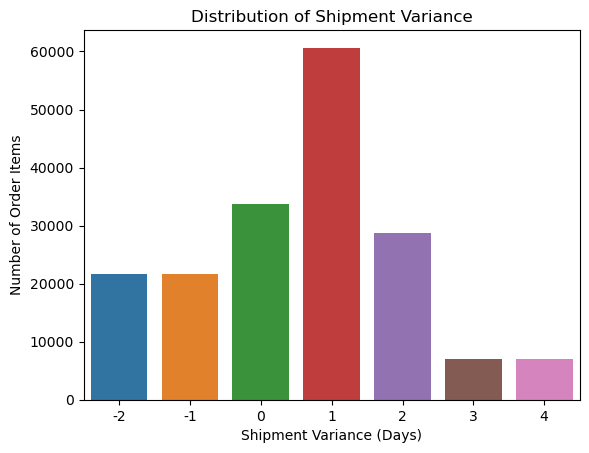

In [85]:
sns.countplot(x=df['shipment variance'])

plt.xlabel("Shipment Variance (Days)")
plt.ylabel("Number of Order Items")
plt.title("Distribution of Shipment Variance")
plt.show()

Shipment variance is concentrated around 0–2 days, with +1 day being the most common outcome, while larger delays are relatively uncommon.

In [86]:
df['shipment variance'].corr(df['Benefit per order'])

-0.005384931797614358

Shipping performance varies substantially, but the variation appears largely disconnected from transaction profitability.

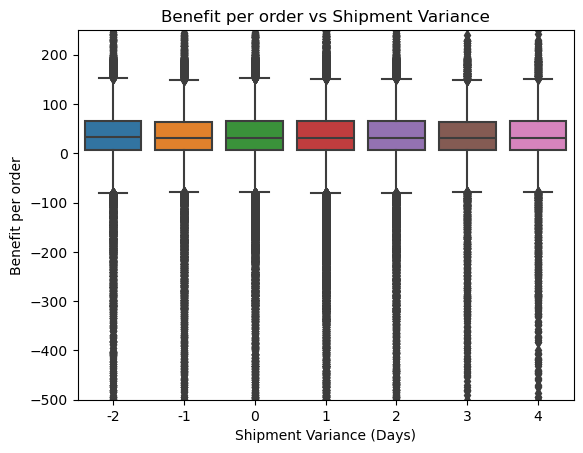

In [87]:
sns.boxplot(x=df["shipment variance"], y=df["Benefit per order"], data=df)
plt.ylim(-500, 250)
plt.xlabel("Shipment Variance (Days)")
plt.ylabel("Benefit per order")
plt.title("Benefit per order vs Shipment Variance")
plt.show()

Benefit per Order remains broadly consistent across shipment variance levels, with no clear relationship between shipping timeliness and transaction profitability.

In [88]:
product_perf = (df.groupby("Product Name", as_index=False).agg(total_sales=('Sales', 'sum'), total_profit=('Order Profit Per Order', 'sum')))
product_perf['profit_margin'] = (product_perf['total_profit'] / product_perf['total_sales'])*100
product_perf.head()

,Product Name,total_sales,total_profit,profit_margin
0,Adult dog supplies,41524.80,3589.26,8.643654
1,Baby sweater,12229.56,1525.03,12.470032
2,Bag Boy Beverage Holder,21116.55,3173.78,15.029823
3,Bag Boy M330 Push Cart,16637.92,2969.11,17.845440
4,Bowflex SelectTech 1090 Dumbbells,5999.90,1190.78,19.846664


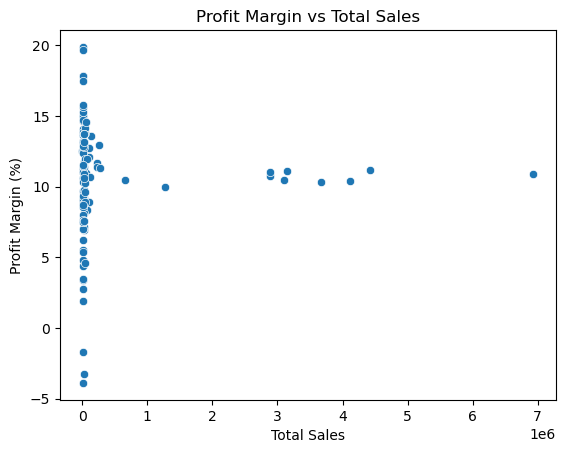

In [89]:
sns.scatterplot(x=product_perf['total_sales'], y=product_perf['profit_margin'])
plt.xlabel("Total Sales")
plt.ylabel("Profit Margin (%)")
plt.title("Profit Margin vs Total Sales")
plt.show()

log to be used for the x-axis

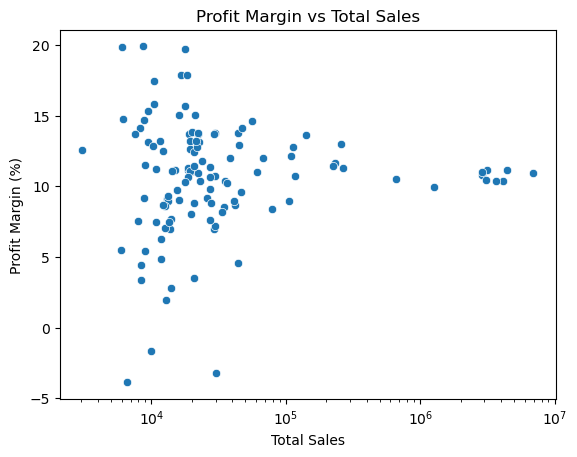

In [90]:
sns.scatterplot(x=product_perf['total_sales'], y=product_perf['profit_margin'])
plt.xscale('log')
plt.xlabel("Total Sales")
plt.ylabel("Profit Margin (%)")
plt.title("Profit Margin vs Total Sales")
plt.show()

In [92]:
spearman_result = stats.spearmanr(product_perf['total_sales'], product_perf['profit_margin'])
print(f"Spearman correlation coefficient: {spearman_result.correlation}, P-value: {spearman_result.pvalue}")

Spearman correlation coefficient: 0.01547012979434606, P-value: 0.8679447471602371


Product sales volume and profit margin show virtually no relationship, indicating that higher sales do not systematically translate into higher margins.

In [93]:
df['Order Item Discount Rate'].describe()

count    180519.000000
mean          0.101668
std           0.070415
min           0.000000
25%           0.040000
50%           0.100000
75%           0.160000
max           0.250000
Name: Order Item Discount Rate, dtype: float64

In [94]:
df['Order Item Discount Rate'].value_counts().sort_index()

Order Item Discount Rate
0.00    10028
0.01    10028
0.02    10028
0.03    10029
0.04    10029
0.05    10029
0.06    10029
0.07    10029
0.09    10029
0.10    10029
0.12    10029
0.13    10029
0.15    10029
0.16    10029
0.17    10029
0.18    10029
0.20    10029
0.25    10029
Name: count, dtype: int64

In [96]:
discounts_profit = df.groupby('Order Item Discount Rate')['Order Profit Per Order'].agg(['mean', 'median', 'std', 'count'])
discounts_profit

,mean,median,std,count
Order Item Discount Rate,,,,
0.00,26.666574,35.20,110.731464,10028
0.01,23.798759,34.65,112.487321,10028
0.02,23.673829,34.40,113.725754,10028
0.03,22.183212,32.78,113.918487,10029
0.04,23.400469,33.69,109.414271,10029
0.05,23.777867,34.19,118.581709,10029
0.06,24.071789,33.07,102.902231,10029
0.07,23.273000,32.73,103.689935,10029
0.09,22.910502,33.12,108.092706,10029


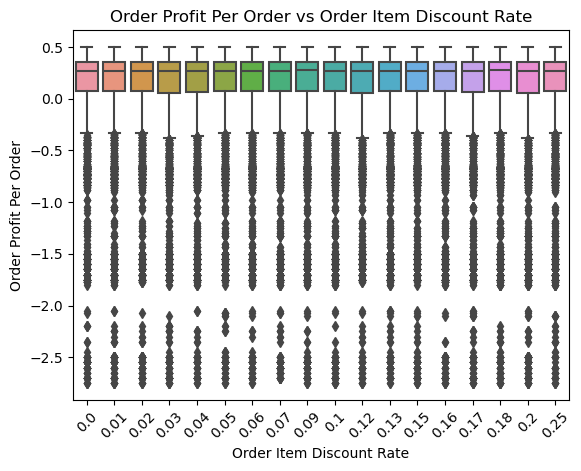

In [ ]:
sns.boxplot(x=df["Order Item Discount Rate"], y=df["Order Item Profit Ratio"])
plt.xlabel("Order Item Discount Rate")
plt.ylabel("Order Item Profit Ratio")
plt.title("Order Item Profit Ratio vs Discount Rate")
plt.xticks(rotation=45)
plt.show()

>As expected, profitability distributions remain broadly similar across discount-rate levels, while the near-perfectly balanced number of observations per discount rate suggests that this dataset's discount structure may be synthetic rather than representative of natural transaction behavior.

In [101]:
customer_perf = (df.groupby("Customer Id", as_index=False)
                 .agg(total_sales=('Sales', 'sum'), total_profit=('Order Profit Per Order', 'sum'), orders=('Order Id', 'nunique')))

In [103]:
customer_perf.head().sort_values(by='total_sales', ascending=False)

,Customer Id,total_sales,total_profit,orders
2,3,3537.68,334.49,5
1,2,1819.73,208.74,4
3,4,1719.63,-439.98,4
4,5,1274.75,309.85,3
0,1,499.95,159.69,1


In [104]:
customer_perf.shape

(20652, 4)

In [105]:
customer_perf_sorted = customer_perf.sort_values(by='total_sales', ascending=False).reset_index(drop=True)

In [106]:
customer_perf_sorted['cumulative_sales'] = customer_perf_sorted['total_sales'].cumsum()

In [107]:
customer_perf_sorted['cumulative_sales_pct'] = customer_perf_sorted['cumulative_sales'] / customer_perf_sorted['total_sales'].sum() * 100

In [109]:
customer_perf_sorted.head(10)

,Customer Id,total_sales,total_profit,orders,cumulative_sales,cumulative_sales_pct
0,791,10524.17,-866.38,13,10524.17,0.028610
1,9371,9299.03,1346.58,11,19823.20,0.053890
2,8766,9296.14,1495.16,11,29119.34,0.079161
3,1657,9223.71,2196.92,11,38343.05,0.104236
4,2641,9130.92,2441.97,11,47473.97,0.129059
5,1288,9019.11,403.11,12,56493.08,0.153578
6,3710,9019.10,1055.13,14,65512.18,0.178096
7,4249,8918.85,439.71,13,74431.03,0.202342
8,5654,8904.95,1045.36,15,83335.98,0.226550
9,5624,8761.98,1178.15,12,92097.96,0.250370


> Sales are broadly distributed across the customer base, with no strong concentration among the highest-value individual customers.